In [1]:
import os
import shutil
import subprocess
import sys

print("Installing kagglehub dataset downloader...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub", "-q"])
import kagglehub

print("Downloading mrmorj/hate-speech-and-offensive-language-dataset from Kaggle...")
downloaded_path = kagglehub.dataset_download("mrmorj/hate-speech-and-offensive-language-dataset")
print(f"Dataset securely cached at: {downloaded_path}")

expected_csv_name = "labeled_data.csv"
source_file = os.path.join(downloaded_path, expected_csv_name)
destination_file = f"./{expected_csv_name}"

if os.path.exists(source_file):
    shutil.copy(source_file, destination_file)
    print(f" {expected_csv_name} successfully transferred to your local workspace root directory!")
else:
    csv_files = [f for f in os.listdir(downloaded_path) if f.endswith('.csv')]
    if csv_files:
        shutil.copy(os.path.join(downloaded_path, csv_files[0]), f"./{expected_csv_name}")
        print(f" Copied identified target source: {csv_files[0]} -> {expected_csv_name}")
    else:
        print("Fatal Error: Could not locate appropriate structural CSV parameters inside source download folder.")

Installing kagglehub dataset downloader...


100%|██████████| 1.01M/1.01M [00:01<00:00, 1.05MB/s]

Extracting files...
Dataset securely cached at: /root/.cache/kagglehub/datasets/mrmorj/hate-speech-and-offensive-language-dataset/versions/1
 labeled_data.csv successfully transferred to your local workspace root directory!


In [ ]:
import subprocess
import sys
import os

print("Installing essential deep learning, quantization, and PEFT libraries...")
packages = [
    "torch>=2.0.0",
    "transformers>=4.36.0",
    "bitsandbytes>=0.41.0",
    "peft>=0.7.0",
    "pandas>=1.5.0",
    "numpy>=1.24.0",
    "scikit-learn>=1.3.0",
    "tqdm>=4.65.0",
    "matplotlib>=3.7.0",
    "seaborn>=0.12.0"
]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

OUTPUTS_DIR = "./outputs_hsol"
os.makedirs(OUTPUTS_DIR, exist_ok=True)
print(f"✓ Core packages active. Target folder generated: {OUTPUTS_DIR}")

Installing essential deep learning, quantization, and PEFT libraries...
✓ Core packages active. Target folder generated: ./outputs_hsol


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

print(" Data Ingestion and Alignment ")
hsol_file_path = "labeled_data.csv"

if not os.path.exists(hsol_file_path):
    raise FileNotFoundError(f" Abort: Target file '{hsol_file_path}' missing from active root directory.")

df_raw = pd.read_csv(hsol_file_path)

# 0 -> Hate Speech, 1 -> Offensive Language, 2 -> Neither
df_hsol = df_raw[['tweet', 'class']].rename(columns={
    'tweet': 'text',
    'class': 'label'
})

print("Original Imbalanced HSOL Distribution Structure:")
print(df_hsol['label'].value_counts())

min_class_count = df_hsol['label'].value_counts().min()
print(f"\nEnforcing uniform data constraint ceiling: {min_class_count} samples per category.")

df_balanced = df_hsol.groupby('label').sample(n=min_class_count, random_state=42).reset_index(drop=True)

print("\nBalanced Distribution Matrix Proof:")
print(df_balanced['label'].value_counts())

train_df, temp_df = train_test_split(df_balanced, test_size=0.2, stratify=df_balanced['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"\nFinal Sub-set Boundaries -> Train Size: {len(train_df)} | Val Size: {len(val_df)} | Test Size: {len(test_df)}")

 Data Ingestion and Alignment 
Original Imbalanced HSOL Distribution Structure:
label
1    19190
2     4163
0     1430
Name: count, dtype: int64

Enforcing uniform data constraint ceiling: 1430 samples per category.

Balanced Distribution Matrix Proof:
label
0    1430
1    1430
2    1430
Name: count, dtype: int64

Final Sub-set Boundaries -> Train Size: 3432 | Val Size: 429 | Test Size: 429


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

print("Initializing Left-Padded Causal Tokenizer Framework")
MODEL_ID = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "left"

class HSOLDset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.texts = dataframe['text'].astype(str).tolist()
        self.labels = dataframe['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        encoding = self.tokenizer(
            self.texts[index],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return (
            encoding['input_ids'].flatten(),
            encoding['attention_mask'].flatten(),
            torch.tensor(self.labels[index], dtype=torch.long)
        )

BATCH_SIZE = 8
train_dataloader = DataLoader(HSOLDset(train_df, tokenizer), batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(HSOLDset(val_df, tokenizer), batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(HSOLDset(test_df, tokenizer), batch_size=BATCH_SIZE, shuffle=False)

print("✓ PyTorch structural DataLoaders prepared successfully.")

Initializing Left-Padded Causal Tokenizer Framework


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

✓ PyTorch structural DataLoaders prepared successfully.


In [5]:
from transformers import AutoModelForSequenceClassification, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, TaskType

print(" Constructing 4-Bit Foundation with 3-Class Head Alignment ")

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=3,
    quantization_config=quantization_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)
model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"]
)

model = get_peft_model(model, peft_config)
print("Active Parameter Configuration Mapping Details:")
model.print_trainable_parameters()

 Constructing 4-Bit Foundation with 3-Class Head Alignment 


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/4.40G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] LlamaForSequenceClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Active Parameter Configuration Mapping Details:
trainable params: 2,258,944 || all params: 1,036,777,472 || trainable%: 0.2179


In [ ]:
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm
import time
from sklearn.metrics import accuracy_score

EPOCHS = 7
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)
total_steps = len(train_dataloader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
training_stats = []
t_start_loop = time.time()

print("Running HSOL Gradient Optimization Pipeline ")
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1} / {EPOCHS}")

    model.train()
    total_train_loss = 0
    skipped_batches = 0

    for step, batch in enumerate(tqdm(train_dataloader, desc="Training Steps")):
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        model.zero_grad()
        outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss

        if torch.isnan(loss):
            skipped_batches += 1
            continue

        total_train_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    effective_batches = len(train_dataloader) - skipped_batches
    avg_train_loss = total_train_loss / effective_batches if effective_batches > 0 else 0
    print(f"  Mean Training Segment Loss: {avg_train_loss:.4f}")

    model.eval()
    total_eval_loss = 0
    val_preds = []
    val_labels = []

    for batch in tqdm(validation_dataloader, desc="Validation Steps"):
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        with torch.no_grad():
            outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)

        loss = outputs.loss
        total_eval_loss += loss.item()

        logits = outputs.logits.detach().float().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        val_preds.extend(np.argmax(logits, axis=1).flatten())
        val_labels.extend(label_ids.flatten())

    avg_val_loss = total_eval_loss / len(validation_dataloader)
    val_accuracy = accuracy_score(val_labels, val_preds)
    print(f"  Validation Loss Segment: {avg_val_loss:.4f} | Validation Accuracy: {val_accuracy * 100:.2f}%")

    training_stats.append({
        'epoch': epoch + 1,
        'Training Loss': avg_train_loss,
        'Valid. Loss': avg_val_loss,
        'Valid. Accur.': val_accuracy
    })

t_end_loop = time.time()
print(f"\n✓ Training Sequence Completed in: {int(t_end_loop - t_start_loop)} Seconds.")

Running HSOL Gradient Optimization Pipeline 

Epoch 1 / 7


Training Steps: 100%|██████████| 429/429 [01:41<00:00,  4.24it/s]


  Mean Training Segment Loss: 0.8754


Validation Steps: 100%|██████████| 54/54 [00:05<00:00, 10.12it/s]


  Validation Loss Segment: 0.5217 | Validation Accuracy: 81.35%

Epoch 2 / 7


...

  Validation Loss Segment: 1.3741 | Validation Accuracy: 82.28%

Epoch 7 / 7


Training Steps: 100%|██████████| 429/429 [01:39<00:00,  4.32it/s]


  Mean Training Segment Loss: 0.0002


Validation Steps: 100%|██████████| 54/54 [00:05<00:00,  9.69it/s]

  Validation Loss Segment: 1.3913 | Validation Accuracy: 82.05%

✓ Training Sequence Completed in: 732 Seconds.


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, classification_report, accuracy_score
import numpy as np
import torch
from tqdm import tqdm

print("Running Final HSOL Validation Set Evaluation Post-Training")
model.eval()
val_preds = []
val_labels = []

for batch in tqdm(validation_dataloader, desc="Validation Evaluation"):
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_labels = batch[2].to(device)

    with torch.no_grad():
        outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)

    logits = outputs.logits.detach().float().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()

    val_preds.extend(np.argmax(logits, axis=1).flatten())
    val_labels.extend(label_ids.flatten())
val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(val_labels, val_preds, average='weighted')
val_accuracy = accuracy_score(val_labels, val_preds)

print("\nFINAL VERIFIED HSOL VALIDATION METRICS")
print(f"Validation Accuracy Score:   {val_accuracy * 100:.2f}%")
print(f"Weighted Precision:          {val_precision * 100:.2f}%")
print(f"Weighted Recall:             {val_recall * 100:.2f}%")
print(f"Weighted F1-Score:           {val_f1 * 100:.2f}%")

print(classification_report(val_labels, val_preds, target_names=['Hate Speech', 'Offensive Language', 'Neither'], digits=4))

Running Final HSOL Validation Set Evaluation Post-Training


Validation Evaluation: 100%|██████████| 54/54 [00:05<00:00,  9.99it/s]


FINAL VERIFIED HSOL VALIDATION METRICS
Validation Accuracy Score:   82.05%
Weighted Precision:          82.13%
Weighted Recall:             82.05%
Weighted F1-Score:           82.09%
                    precision    recall  f1-score   support

       Hate Speech     0.7448    0.7552    0.7500       143
Offensive Language     0.8112    0.8112    0.8112       143
           Neither     0.9078    0.8951    0.9014       143

          accuracy                         0.8205       429
         macro avg     0.8213    0.8205    0.8209       429
      weighted avg     0.8213    0.8205    0.8209       429



In [8]:
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix
print("Running Hidden HSOL Test Set Evaluation")
model.eval()
test_preds = []
test_labels = []

for batch in tqdm(test_dataloader, desc="Testing Evaluation"):
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_labels = batch[2].to(device)

    with torch.no_grad():
        outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)

    logits = outputs.logits.detach().float().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()

    test_preds.extend(np.argmax(logits, axis=1).flatten())
    test_labels.extend(label_ids.flatten())

precision, recall, f1, _ = precision_recall_fscore_support(test_labels, test_preds, average='weighted')
test_accuracy = accuracy_score(test_labels, test_preds)

print("\nFINAL VERIFIED HSOL TEST METRICS")
print(f"Test Accuracy Score:   {test_accuracy * 100:.2f}%")
print(f"Weighted Precision:    {precision * 100:.2f}%")
print(f"Weighted Recall:       {recall * 100:.2f}%")
print(f"Weighted F1-Score:     {f1 * 100:.2f}%")
print(classification_report(test_labels, test_preds, target_names=['Hate Speech', 'Offensive Language', 'Neither'], digits=4))

Running Hidden HSOL Test Set Evaluation


Testing Evaluation: 100%|██████████| 54/54 [00:05<00:00, 10.05it/s]


FINAL VERIFIED HSOL TEST METRICS
Test Accuracy Score:   80.65%
Weighted Precision:    80.75%
Weighted Recall:       80.65%
Weighted F1-Score:     80.64%
                    precision    recall  f1-score   support

       Hate Speech     0.7368    0.7832    0.7593       143
Offensive Language     0.8030    0.7413    0.7709       143
           Neither     0.8828    0.8951    0.8889       143

          accuracy                         0.8065       429
         macro avg     0.8075    0.8065    0.8064       429
      weighted avg     0.8075    0.8065    0.8064       429



/tmp/ipykernel_5982/1017635454.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Category', data=counts, palette='viridis', ax=ax)


Visualization plots safely rendered to folder path: ./outputs_hsol


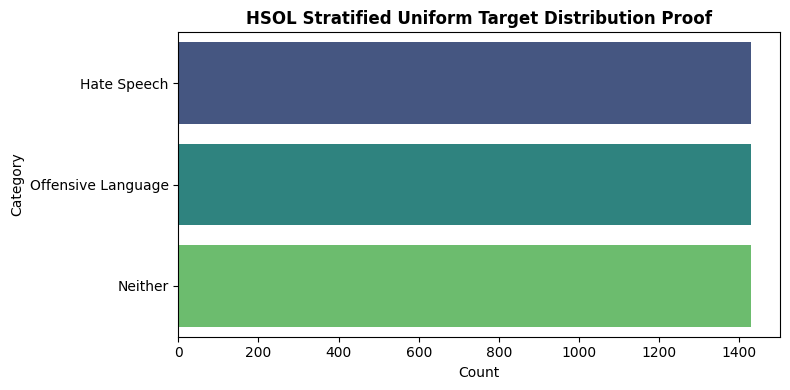

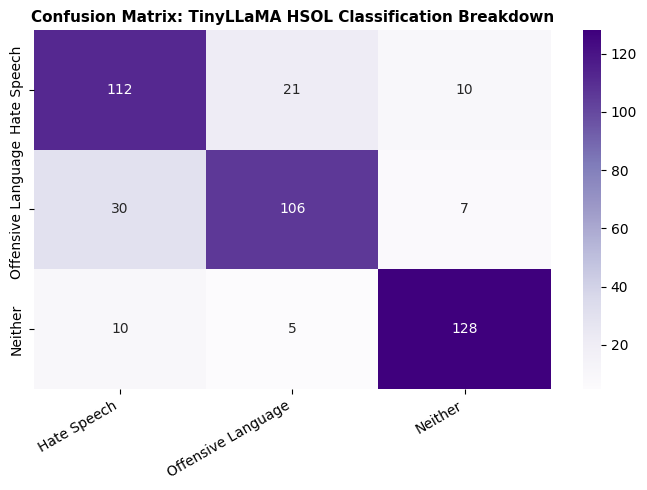

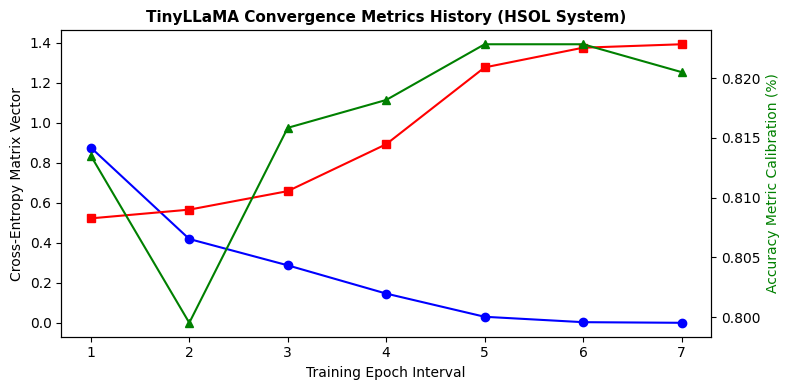

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

hsol_names = ['Hate Speech', 'Offensive Language', 'Neither']

counts = df_balanced['label'].value_counts().reset_index()
counts.columns = ['Class_ID', 'Count']
counts['Category'] = counts['Class_ID'].map({0: 'Hate Speech', 1: 'Offensive Language', 2: 'Neither'})
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x='Count', y='Category', data=counts, palette='viridis', ax=ax)
ax.set_title('HSOL Stratified Uniform Target Distribution Proof', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/hsol_data_distribution.png', dpi=300)

cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=hsol_names, yticklabels=hsol_names, ax=ax)
ax.set_title('Confusion Matrix: TinyLLaMA HSOL Classification Breakdown', fontsize=11, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/hsol_confusion_matrix.png', dpi=300)

stats_df = pd.DataFrame(training_stats)
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(stats_df['epoch'], stats_df['Training Loss'], 'b-o', label='Training Loss')
ax1.plot(stats_df['epoch'], stats_df['Valid. Loss'], 'r-s', label='Validation Loss')
ax1.set_xlabel('Training Epoch Interval')
ax1.set_ylabel('Cross-Entropy Matrix Vector')
ax2 = ax1.twinx()
ax2.plot(stats_df['epoch'], stats_df['Valid. Accur.'], 'g-^', label='Validation Accuracy')
ax2.set_ylabel('Accuracy Metric Calibration (%)', color='green')
plt.title('TinyLLaMA Convergence Metrics History (HSOL System)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/hsol_training_history.png', dpi=300)

print(f"Visualization plots safely rendered to folder path: {OUTPUTS_DIR}")

In [10]:
import shutil
from google.colab import files

MODEL_SAVE_PATH = f"{OUTPUTS_DIR}/TinyLlama-1.1B-HSOL-LoRA"
print(f"Packaging Fine-Tuned Model Weights to Destination: {MODEL_SAVE_PATH}")
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

ZIP_NAME = "tinyllama_lora_hsol_results"
print(f"Compressing plots and checkpoint arrays into {ZIP_NAME}.zip...")
shutil.make_archive(ZIP_NAME, 'zip', OUTPUTS_DIR)

print("Zip packaging complete. Initializing local system browser download...")
files.download(f"{ZIP_NAME}.zip")

Packaging Fine-Tuned Model Weights to Destination: ./outputs_hsol/TinyLlama-1.1B-HSOL-LoRA
Compressing plots and checkpoint arrays into tinyllama_lora_hsol_results.zip...
Zip packaging complete. Initializing local system browser download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>